In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

import string
import re
from urllib.parse import urlparse

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [43]:
meajor = load_dataset("simlab-vs/meajor_cleaned_preprocessed")

df_base = meajor["train"].to_pandas()
old_cols = set(list(df_base.columns))
df = df_base.copy()

# Engineer features

df["sender_domain_length"] = df["sender_domain"].str.len()
df["subject_length"] = df["subject"].str.len()
df["body_length"] = df["body"].str.len()
df["email_length"] = df["subject_length"].add(df["body_length"], fill_value=0)
df["punctuation_count"] = df["body"].apply(lambda body:
    sum(c in string.punctuation for c in body) if body is not None else None)

added = list(set(list(df.columns)) - old_cols)
print("Original features:")
print(old_cols)
print("Engineered features:")
added

Original features:
{'body', 'subject', 'sender_domain', 'receiver_domain', 'attachment_count', 'attachment_types', 'content_types', 'sender', 'date', 'url_length_avg', 'language', 'url_count', 'receiver', 'label', 'source', 'urls', 'url_length_max', 'url_subdom_max', 'has_attachments', 'url_subdom_avg'}
Engineered features:


['body_length',
 'email_length',
 'sender_domain_length',
 'subject_length',
 'punctuation_count']

In [44]:
# Further processing & split

features = df.copy()

# Handle "NaN"s in numerical & countvec values

numeric_cats = ["subject_length", "body_length", "email_length",
                    "sender_domain_length",
                    "url_count", "url_length_max", "url_length_avg",
                    "url_subdom_max", "url_subdom_avg",
                    "attachment_count", "punctuation_count"]
numerics = dict.fromkeys(numeric_cats, 0) # Make them all 0s
onehot_cats = ["source", "has_attachments"]
multilabel_cats = ["content_types", "attachment_types"]
count_cats = ["sender_domain", "receiver_domain", "urls"]
tfidf_cats = ["subject", "body"]
texts = dict.fromkeys(
    onehot_cats + count_cats + multilabel_cats + tfidf_cats, "")
fill_dict = numerics | texts

features.fillna(fill_dict, inplace=True)
tkeys = list(texts.keys())
df[tkeys] = df[tkeys].astype(str)

features = features[features["language"].fillna("").str.split(";").apply(
    lambda langs: set(langs) == {"en"})] # Only English
for col in multilabel_cats: # Prepare for multilabel binarizer
    features[col] = features[col].fillna("").str.split(";")
features.drop(columns=["sender", "receiver", "language"], inplace=True)
features = features[features["label"] != "nan"]
target = features["label"]
features.drop(columns=["label"], inplace=True)

"""
mlb_features = []

for col in multilabel_cats:
    cleaned = features[col].fillna("").astype(str).str.split(";")
    mlb = MultiLabelBinarizer()
    mlb_matrix = mlb.fit_transform(cleaned)
    block = pd.DataFrame(
        mlb_matrix,
        columns=[f"{col}__{cls}" for cls in mlb.classes_],
        index=features.index
    )
    mlb_features.append(pd.DataFrame(mlb_matrix, index=features.index))

mlb_block = pd.concat(mlb_features, axis=1).astype(float)
mlb_block.columns = mlb_block.columns.astype(str)
features = pd.concat([features.drop(columns=multilabel_cats), mlb_block], axis=1)
features.columns = features.columns.astype(str)

for col in mlb_block.columns:
  print(features[col].dtype)
"""

class MultiLabelBinarizerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.mlb = MultiLabelBinarizer()

    def fit(self, X, y=None):
        # Expects a pandas Series or 1D array of iterables
        self.mlb.fit(X.squeeze())
        return self

    def transform(self, X):
        return self.mlb.transform(X.squeeze())

    def get_feature_names_out(self, input_features=None):
        return self.mlb.classes_

print(features.isna().sum())
# print(features.value_counts())
print(target.value_counts())

# Test-train split

X_train, X_test, y_train, y_test = train_test_split(
    features, target,
    test_size=0.2,    # 20% testing, 80% training
    random_state=42,  # Reproducibility
    stratify=target # Same % of 0/1 in test & train
)

sender_domain           0
receiver_domain         0
date                    0
subject                 0
content_types           0
body                    0
urls                    0
url_count               0
url_length_max          0
url_length_avg          0
url_subdom_max          0
url_subdom_avg          0
attachment_count        0
has_attachments         0
attachment_types        0
source                  0
sender_domain_length    0
subject_length          0
body_length             0
email_length            0
punctuation_count       0
dtype: int64
label
0.0    60339
1.0    43419
Name: count, dtype: int64


In [46]:
# Actual training pipeline

# mlb_cols = mlb_block.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("subject", TfidfVectorizer(
            stop_words="english",
            max_features=1000,
            ngram_range=(1, 3)
        ), "subject"),

        ("body", TfidfVectorizer(
            stop_words="english",
            max_features=3000,
            ngram_range=(1, 3)
        ), "subject"),

        ("sender_domain", CountVectorizer(
            token_pattern=r"[^;]+", # Split by semicolon
        ), "sender_domain"),

        ("receiver_domain", CountVectorizer(
            token_pattern=r"[^;]+", # Split by semicolon
        ), "receiver_domain"),

        ("urls", CountVectorizer(), "urls"),

        ("numeric", StandardScaler(), numeric_cats),

        ("onehot", OneHotEncoder(handle_unknown="ignore"), onehot_cats),

        ("content", MultiLabelBinarizerTransformer(), "content_types"),

        ("attatchments", MultiLabelBinarizerTransformer(), "attachment_types")
    ]
)

model = Pipeline([
    ("preproccess", preprocessor),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preproccess',
                 ColumnTransformer(transformers=[('subject',
                                                  TfidfVectorizer(max_features=1000,
                                                                  ngram_range=(1,
                                                                               3),
                                                                  stop_words='english'),
                                                  'subject'),
                                                 ('body',
                                                  TfidfVectorizer(max_features=3000,
                                                                  ngram_range=(1,
                                                                               3),
                                                                  stop_words='english'),
                                                  'subject'),
                                                 ('sender_domain',
                                                  CountVectorizer(token_pattern='[^;]+'),
                                                  'sender_domain'),
                                                 ('receiver_domain',
                                                  CountV...
                                                   'url_length_avg',
                                                   'url_subdom_max',
                                                   'url_subdom_avg',
                                                   'attachment_count',
                                                   'punctuation_count']),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['source',
                                                   'has_attachments']),
                                                 ('content',
                                                  MultiLabelBinarizerTransformer(),
                                                  'content_types'),
                                                 ('attatchments',
                                                  MultiLabelBinarizerTransformer(),
                                                  'attachment_types')])),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['message/delivery-status'] will be ignored
  warnings.warn(


Predicting: 0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
108680    1.0
108681    1.0
108682    0.0
108683    0.0
108684    1.0
Name: label, Length: 103758, dtype: float64
Training samples: 83006
Testing samples: 20752

Model performance:
Accuracy: 0.9867
Precision: 0.9867
Recall: 0.9867
F1 Score: 0.9867

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99     12068
         1.0       0.99      0.98      0.98      8684

    accuracy                           0.99     20752
   macro avg       0.99      0.99      0.99     20752
weighted avg       0.99      0.99      0.99     20752



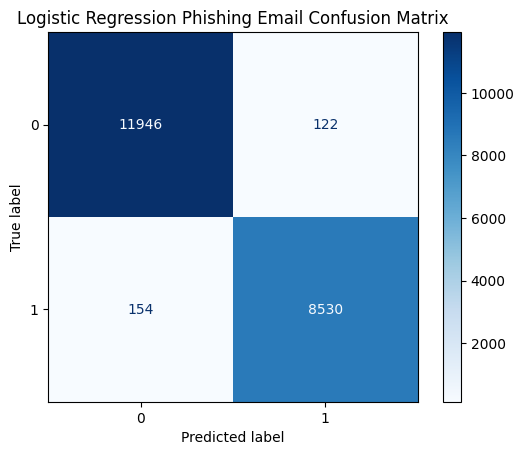

In [47]:
# Testing (credit to Vani for this code)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)
recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)
f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print("Predicting:", target)
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nModel performance:")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1 Score:", round(f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

display.plot(cmap="Blues")
plt.title("Logistic Regression Phishing Email Confusion Matrix")
plt.show()